---
subtitle: "Lab 01 - Classification"
jupyter: python3
execute:
  enabled: true
---

<a href="https://colab.research.google.com/github/w4bo/AA2627-unibo-mldm/blob/master/slides/lab-03-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## From lecture to lab

In this lab you will build classification workflows with the ARFF datasets in `slides/datasets`.

- ARFF, short for Attribute-Relation File Format, is a plain-text dataset format that defines a relation, its attributes, and the data records.
- ARFF stores a relation name, attribute declarations, and data rows.

```
@relation bank-data

@attribute id {ID12101,ID12102,...}
@attribute age numeric
@attribute sex {FEMALE,MALE}
@attribute children numeric
...
@attribute pep {YES,NO}

@data
ID12101,48,FEMALE,INNER_CITY,17546,NO,1,NO,NO,NO,NO,YES
ID12102,40,MALE,TOWN,30085.1,YES,3,YES,NO,YES,YES,NO
```

# By the end, you should be able to:

- inspect data and identify features, targets, missing values, and identifiers;
- build leakage-safe preprocessing pipelines for numeric and categorical features;
- distinguish training, cross-validation, and test performance;
- compare a baseline, logistic regression, a decision tree, and k-nearest neighbours;
- interpret confusion matrices, precision, recall, F1;
- tune a model without using the test set;
- evaluate a selected model on a supplied external test set.

# Setup and reproducibility

- The notebook uses packages included in standard Google Colab runtimes.
- If a local environment is missing one, run the installation command: `pip install -q numpy pandas matplotlib scikit-learn`
- Run the notebook from top to bottom.
- All random operations use the same seed. *Why?*

<details>
<summary>Answer</summary>

Random operations are seeded to ensure reproducibility of results. This means that every time the notebook is run, the same random numbers will be generated, leading to consistent outputs and comparison of results.
</details>

In [1]:
#| echo: false
#| output: false

!pip install -q numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
#| echo: false
#| output: false

from pathlib import Path
from urllib.request import urlopen
import csv
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay,accuracy_score,balanced_accuracy_score,classification_report,f1_score)
from sklearn.model_selection import (GridSearchCV,StratifiedKFold,cross_validate,train_test_split,)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")


Matplotlib is building the font cache; this may take a moment.


# Load ARFF files without extra dependencies

`find_dataset` makes paths work whether the notebook starts in the repository root or in `slides/`.

In [3]:
#| echo: false
#| output: false

DATASET_BASE_URL = "https://raw.githubusercontent.com/w4bo/AA2627-unibo-mldm/refs/heads/main/slides/datasets/"

ATTRIBUTE_RE = re.compile(
    r"^@attribute\s+(?:'([^']+)'|\"([^\"]+)\"|(\S+))\s+(.+)$",
    flags=re.IGNORECASE,
)


def find_dataset(filename):
    candidates = [
        Path("datasets") / filename,
        Path("slides") / "datasets" / filename,
        Path.cwd() / "datasets" / filename,
        Path.cwd() / "slides" / "datasets" / filename,
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    return f"{DATASET_BASE_URL}{filename}"


def load_dense_arff(filename):
    source = find_dataset(filename)
    attributes = []
    data_lines = []
    in_data = False

    if isinstance(source, Path):
        raw_lines = source.read_text(encoding="utf-8-sig").splitlines()
    else:
        with urlopen(source) as response:
            raw_lines = response.read().decode("utf-8-sig").splitlines()

    for raw_line in raw_lines:
        line = raw_line.strip()
        if not line or line.startswith("%"):
            continue
        if line.lower() == "@data":
            in_data = True
            continue
        if not in_data:
            match = ATTRIBUTE_RE.match(line)
            if match:
                name = next(group for group in match.groups()[:3] if group is not None)
                attributes.append((name, match.group(4).strip()))
        else:
            data_lines.append(line)

    rows = list(csv.reader(data_lines, quotechar="'", skipinitialspace=True))
    names = [name for name, _ in attributes]
    if not names or any(len(row) != len(names) for row in rows):
        raise ValueError(f"Unsupported or malformed ARFF file: {source}")

    frame = pd.DataFrame(rows, columns=names).replace("?", np.nan)
    for name, declared_type in attributes:
        if declared_type.lower() in {"numeric", "real", "integer"}:
            frame[name] = pd.to_numeric(frame[name], errors="coerce")
        else:
            values = frame[name].astype("string").str.strip()
            frame[name] = values.astype(object).where(values.notna(), np.nan)
    return frame


In [4]:
bank = load_dense_arff("bank-data.arff")
census_train = load_dense_arff("CensusTraining.arff")
census_test = load_dense_arff("CensusTest.arff")
nursery = load_dense_arff("nurseryTrain.arff")

dataset_catalog = pd.DataFrame(
    {
        "rows": [len(bank), len(census_train), len(census_test), len(nursery)],
        "columns": [bank.shape[1], census_train.shape[1], census_test.shape[1], nursery.shape[1]],
        "target": ["pep", "class", "class", "class"],
    },
    index=["Bank", "Census train", "Census test", "Nursery"],
)
dataset_catalog

,rows,columns,target
Bank,600,12,pep
Census train,1000,15,class
Census test,31561,15,class
Nursery,10000,9,class


# Checkpoint - understand the data contract

1. Which datasets have a separate, supplied test set?
2. Why should the Census test set remain untouched during model selection?

<details>
<summary>Answer</summary>

Only Census has an explicit training/test pair. Looking at its test results while choosing features or hyperparameters leaks test information into the model-selection process and makes the final estimate optimistic.
</details>

# Bank dataset

# Bank Data: an end-to-end binary classification workflow

The task is to predict whether a customer buys a personal equity plan (`pep`). We will

1. reserve one test set,
2. compare candidate workflows by cross-validation on the training set,
3. tune one model, and
4. evaluate it once on the test set.

# Audit the Bank dataset

A useful first audit checks shape, types, missingness, target balance, suspicious identifiers, and feature distributions.

- An identifier can let a model memorize rows without learning a reusable pattern.

In [5]:
bank.head()


,id,age,sex,region,income,married,children,car,save_act,current_act,mortgage,pep
0,ID12101,48,FEMALE,INNER_CITY,17546.0,NO,1,NO,NO,NO,NO,YES
1,ID12102,40,MALE,TOWN,30085.1,YES,3,YES,NO,YES,YES,NO
2,ID12103,51,FEMALE,INNER_CITY,16575.4,YES,0,YES,YES,YES,NO,NO
3,ID12104,23,FEMALE,TOWN,20375.4,YES,3,NO,NO,YES,NO,NO
4,ID12105,57,FEMALE,RURAL,50576.3,YES,0,NO,YES,NO,NO,NO


# Data profiling


In [6]:
bank.info()


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           600 non-null    object 
 1   age          600 non-null    int64  
 2   sex          600 non-null    object 
 3   region       600 non-null    object 
 4   income       600 non-null    float64
 5   married      600 non-null    object 
 6   children     600 non-null    int64  
 7   car          600 non-null    object 
 8   save_act     600 non-null    object 
 9   current_act  600 non-null    object 
 10  mortgage     600 non-null    object 
 11  pep          600 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 56.4+ KB


In [7]:
#| echo: false
#| output: false

bank.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,600,600,ID12101,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,600.0,NaN,NaN,NaN,42.395,14.424947,18.0,30.0,42.0,55.25,67.0
sex,600,2,FEMALE,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,600,4,INNER_CITY,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,600.0,NaN,NaN,NaN,27524.031217,12899.468246,5014.21,17264.5,24925.3,36172.675,63130.1
married,600,2,YES,396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
children,600.0,NaN,NaN,NaN,1.011667,1.056752,0.0,0.0,1.0,2.0,3.0
car,600,2,NO,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
save_act,600,2,YES,414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_act,600,2,YES,455,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Bank target counts


In [8]:
bank["pep"].value_counts().to_frame("count")


,count
pep,
NO,326
YES,274


In [9]:
bank["pep"].value_counts(normalize=True).rename("proportion").to_frame()


,proportion
pep,
NO,0.543333
YES,0.456667


## (Simple) Data preprocessing

In [10]:
bank = bank.replace({"YES": 1, "NO": 0})
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           600 non-null    object 
 1   age          600 non-null    int64  
 2   sex          600 non-null    object 
 3   region       600 non-null    object 
 4   income       600 non-null    float64
 5   married      600 non-null    object 
 6   children     600 non-null    int64  
 7   car          600 non-null    object 
 8   save_act     600 non-null    object 
 9   current_act  600 non-null    object 
 10  mortgage     600 non-null    object 
 11  pep          600 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 56.4+ KB


## Data understanding

Pearson correlation measures the strength and direction of a linear relationship between two numeric features.

- Values near `1` indicate a strong positive relationship, values near `-1` a strong negative relationship, and values near `0` little linear relationship.

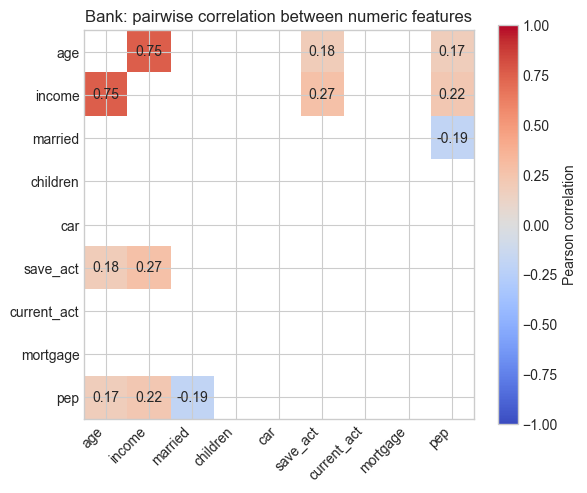

In [11]:
#| echo: false

bank_numeric_features = bank.drop(columns=["id", "region", "sex"])#.select_dtypes(include="number")
bank_correlations = bank_numeric_features.corr()
correlation_mask = np.eye(len(bank_correlations), dtype=bool) | (bank_correlations.abs() < 0.15)
bank_correlations_filtered = bank_correlations.mask(correlation_mask)

fig, ax = plt.subplots(figsize=(6, 5))
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")
image = ax.imshow(bank_correlations_filtered, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(bank_correlations.columns)), bank_correlations.columns, rotation=45, ha="right")
ax.set_yticks(range(len(bank_correlations.index)), bank_correlations.index)
for row in range(len(bank_correlations.index)):
    for column in range(len(bank_correlations.columns)):
        value = bank_correlations_filtered.iloc[row, column]
        if pd.notna(value):
            ax.text(column, row, f"{value:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Bank: pairwise correlation between numeric features")
plt.tight_layout()

## Data understanding

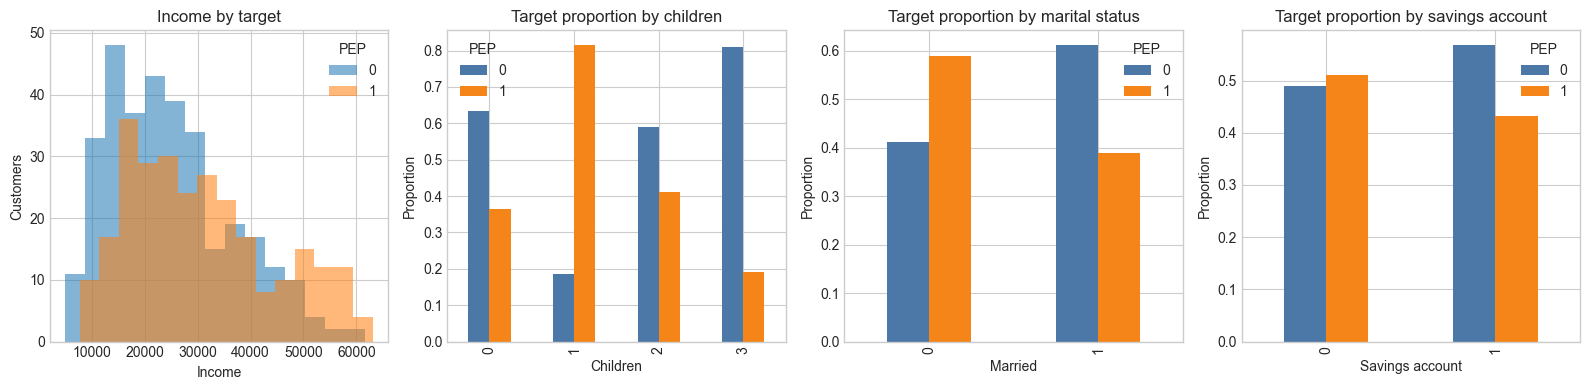

In [12]:
#| echo: false

features_to_plot = [
    ("income", "hist", "Income by target", "Income"),
    ("children", "bar", "Target proportion by children", "Children"),
    ("married", "bar", "Target proportion by marital status", "Married"),
    ("save_act", "bar", "Target proportion by savings account", "Savings account"),
]

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(16, 4))

for ax, (feature, plot_kind, title, xlabel) in zip(axes, features_to_plot):
    if plot_kind == "hist":
        for label, group in bank.groupby("pep"):
            ax.hist(group[feature], bins=15, alpha=0.55, label=label)
        ax.set(ylabel="Customers")
    else:
        pd.crosstab(bank[feature], bank["pep"], normalize="index").plot.bar(
            ax=ax, color=["#4C78A8", "#F58518"]
        )
        ax.set(ylabel="Proportion")
    ax.set(title=title, xlabel=xlabel)
    ax.legend(title="PEP")

plt.tight_layout()

## Exercise - decide what enters the model

Before running the next cell:

1. Should `id` be a feature?
2. Which columns are numeric and which are categorical?
3. Is accuracy alone likely to be grossly misleading for this target?

<details>
<summary>Answer</summary>

- `id` should be removed: it uniquely names records and has no intended predictive meaning.
- `age`, `income`, and `children` are numeric; the remaining inputs are categorical.
- The target is not extremely imbalanced, so accuracy is informative, but balanced accuracy, F1, and the confusion matrix still expose different kinds of error.
</details>

## Make a single stratified holdout split

The test set is placed “in a vault” until model selection is complete.

- Stratification preserves the target proportions in both partitions.

In [13]:
#| echo: false

X_bank = bank.drop(columns=["pep", "id"])
y_bank = bank["pep"].astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X_bank,
    y_bank,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_bank,
)

split_balance = pd.concat(
    [
        y_train.value_counts(normalize=True).rename("train"),
        y_test.value_counts(normalize=True).rename("test"),
    ],
    axis=1,
)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
split_balance


Training shape: (450, 10)
Test shape: (150, 10)


,train,test
pep,,
0,0.542222,0.546667
1,0.457778,0.453333


## Build leakage-safe preprocessing

A `Pipeline` learns preprocessing from each training fold only.

- Numeric columns: standardization when a model is sensitive to feature scale.
- Categorical columns: one-hot encoding.
- Unknown categories are ignored so prediction does not fail on a new category.

In [14]:
#| echo: false

def make_preprocessor(X, scale_numeric=True, impute_missing=False):
    numeric = X.select_dtypes(include="number").columns.tolist()
    categorical = X.columns.difference(numeric).tolist()

    if impute_missing:
        numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
        if scale_numeric:
            numeric_steps.append(("scaler", StandardScaler()))
        numeric_transformer = Pipeline(numeric_steps)
        categorical_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ])
    else:
        numeric_transformer = StandardScaler() if scale_numeric else "passthrough"
        categorical_transformer = OneHotEncoder(handle_unknown="ignore")

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric),
            ("categorical", categorical_transformer, categorical),
        ]
    )


def classifier_pipeline(X, model, scale_numeric=True, impute_missing=False):
    return Pipeline([
        (
            "preprocess",
            make_preprocessor(
                X,
                scale_numeric=scale_numeric,
                impute_missing=impute_missing,
            ),
        ),
        ("model", model),
    ])

classifier_pipeline(X_train, DecisionTreeClassifier(), scale_numeric=True,)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

## Metric guide

The right metric depends on the cost of errors. A business policy needs those costs; the dataset alone cannot supply them.

| Metric | Formula | Main question | Common limitation |
|---|---|---|---|
| Accuracy | $\frac{TP+TN}{TP+TN+FP+FN}$ | How often is the predicted label correct? | Can hide minority-class failure |
| Precision | $\frac{TP}{TP+FP}$ | When the model predicts positive, how often is it right? | Falls when false positives rise |
| Recall (Sensitivity) | $\frac{TP}{TP+FN}$ | Of actual positives, how many are found? | Can be raised by predicting positive often |
| F1 | $\frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$ | How strong is the precision-recall trade-off? | Hides which component is weak |
| Specificity | $\frac{TN}{TN+FP}$ | Of actual negatives, how many are found? | Can be raised by predicting negative often |
| Balanced accuracy | $\frac{\text{sensitivity} + \text{specificity}}{2}$ | How good is average recall across classes? | Gives every class equal weight |

Balanced accuracy averages sensitivity (recall on positives) and specificity (recall on negatives), giving each class equal weight.

- A model that never predicts positive gets balanced accuracy = 0.5, exposing the failure plain accuracy hides.

## Compare different models... how?

## Compare different models with stratified cross-validation

Always include a simple baseline.

- `DummyClassifier` reveals whether a learned model improves on predicting the most common class.
- We report the mean and standard deviation across five folds. The same folds are used for every candidate.

In [15]:
#| echo: false

models = {
    "Most-frequent baseline": classifier_pipeline(
        X_train, DummyClassifier(strategy="most_frequent"), scale_numeric=False
    ),
    "Decision tree": classifier_pipeline(
        X_train,
        DecisionTreeClassifier(max_depth=5, min_samples_leaf=8, random_state=RANDOM_STATE),
        scale_numeric=False,
    ),
    "k-NN (k=9)": classifier_pipeline(X_train, KNeighborsClassifier(n_neighbors=9)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1_macro",
}

cv_rows = []
for name, workflow in models.items():
    scores = cross_validate(workflow, X_train, y_train, cv=cv, scoring=scoring)
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_sd"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).set_index("model").sort_values(
    "balanced_accuracy_mean", ascending=False
)
# cv_results.round(3)

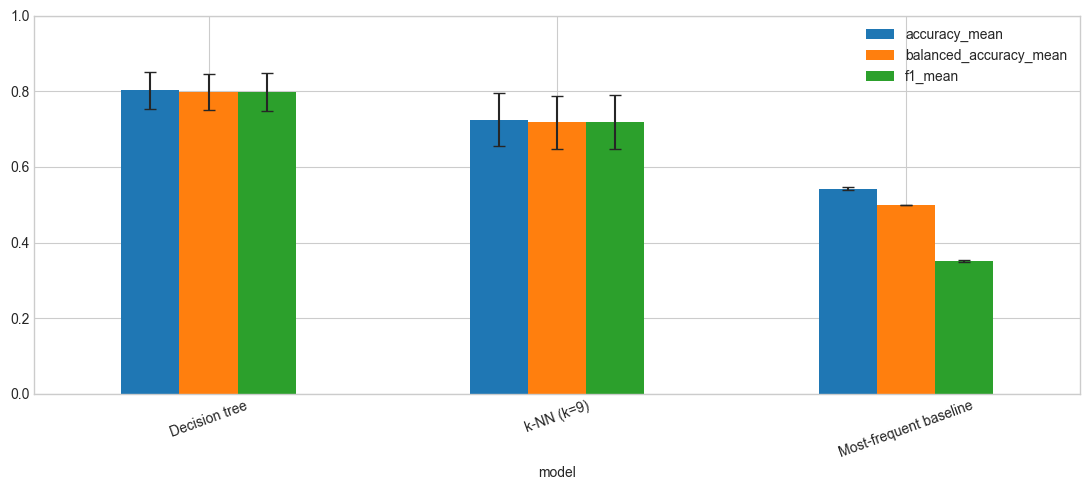

In [16]:
cv_means = cv_results[["accuracy_mean", "balanced_accuracy_mean", "f1_mean"]]
cv_standard_deviations = cv_results[["accuracy_sd", "balanced_accuracy_sd", "f1_sd"]].rename(columns=lambda name: name.replace("_sd", "_mean"))
ax = cv_means.plot.bar(yerr=cv_standard_deviations, capsize=4, figsize=(11, 5), ylim=(0, 1), rot=20,)
ax.legend()
plt.tight_layout()

## Checkpoint - read cross-validation results

1. Does every learned model beat the baseline?
2. Are the model rankings identical for every metric?
3. Why is the standard deviation useful?
4. Why have we still not inspected test-set scores?

The standard deviation describes sensitivity to the particular validation fold.

- Small mean differences accompanied by large fold variation should not be over-interpreted.

## Tune tree complexity 

An unconstrained tree can memorize the training set. 

**Grid search cross-validation (`GridSearchCV`)** systematically tries every parameter combination in a specified grid.

- For each combination, it splits the training data into folds, trains on all but one fold, validates on the remaining fold, and rotates the validation fold.
- It then averages the validation scores and refits the best combination on all training data. 
- This provides a more stable comparison than choosing parameters from a single split.

In [17]:
tree_workflow = classifier_pipeline(X_train, DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_STATE), scale_numeric=False,)
tree_grid = GridSearchCV(
    tree_workflow,
    param_grid={  # Here the grid varies tree `max_depth` and `min_samples_leaf`.
        "model__max_depth": [2, 3, 4, 5, 7, None],
        "model__min_samples_leaf": [1, 5, 10, 20],
    },
    scoring="balanced_accuracy",
    cv=cv, n_jobs=1, return_train_score=True,
)
tree_grid.fit(X_train, y_train)
print("Best parameters:", tree_grid.best_params_)
print("Best mean CV balanced accuracy:", round(tree_grid.best_score_, 3))

Best parameters: {'model__max_depth': 7, 'model__min_samples_leaf': 5}
Best mean CV balanced accuracy: 0.839


## Tune tree complexity using training data only

In [18]:
#| echo: false

grid_results = pd.DataFrame(tree_grid.cv_results_)
grid_view = grid_results[[
    "param_model__max_depth",
    "param_model__min_samples_leaf",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].sort_values("rank_test_score")
grid_view.head(10).round(3)

,param_model__max_depth,param_model__min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score
17,7,5,0.902,0.839,0.040,1
21,None,5,0.909,0.837,0.043,2
16,7,1,0.940,0.805,0.047,3
18,7,10,0.861,0.802,0.026,4
22,None,10,0.861,0.802,0.026,4
12,5,1,0.852,0.799,0.039,6
13,5,5,0.843,0.793,0.044,7
20,None,1,1.000,0.781,0.047,8
14,5,10,0.822,0.757,0.019,9
19,7,20,0.815,0.756,0.023,10


## Exercise - diagnose overfitting

1. Which setting overfits most strongly?
2. How do `max_depth` and `min_samples_leaf` control complexity?
3. Is the configuration with the highest training score necessarily the selected one?

<details>
<summary>Answer</summary>

Deep trees with very small leaves usually have the largest gap. Restricting depth limits sequential splits; increasing minimum leaf size prevents rules based on very few rows. Grid search selects the highest mean validation score, not the highest training score.
</details>

## Final Bank evaluation

Now evaluate the tuned workflow once on the held-out test set. 

In [19]:
#| echo: false

best_bank_model = tree_grid.best_estimator_
bank_pred = best_bank_model.predict(X_test)
bank_proba = best_bank_model.predict_proba(X_test)
positive_index = list(best_bank_model.classes_).index(1)
bank_score = bank_proba[:, positive_index]

bank_test_metrics = pd.Series({
    "accuracy": accuracy_score(y_test, bank_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, bank_pred),
    "macro_f1": f1_score(y_test, bank_pred, average="macro"),
}, name="test_score")

print(classification_report(y_test, bank_pred, digits=3))

              precision    recall  f1-score   support

           0      0.880     0.890     0.885        82
           1      0.866     0.853     0.859        68

    accuracy                          0.873       150
   macro avg      0.873     0.872     0.872       150
weighted avg      0.873     0.873     0.873       150



## Final Bank evaluation

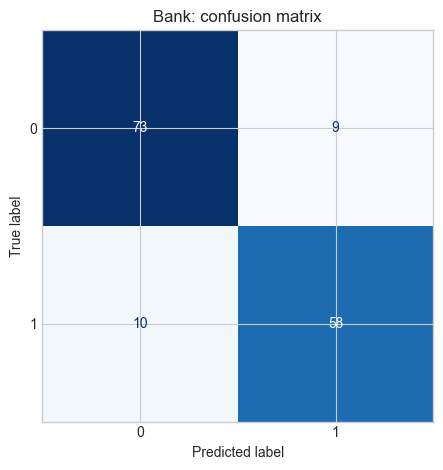

In [20]:
#| echo: false

ConfusionMatrixDisplay.from_predictions(
    y_test, bank_pred, labels=[0, 1], cmap="Blues", colorbar=False
)
plt.title("Bank: confusion matrix")
plt.tight_layout()

In [21]:
bank_test_metrics.to_frame().round(3)

,test_score
accuracy,0.873
balanced_accuracy,0.872
macro_f1,0.872


## Inspect the model, not just its score

Permutation importance asks: **how much worse does the fitted workflow become if one feature is made uninformative?**

For each feature, scikit-learn:

1. computes the baseline score of the already fitted model;
2. randomly shuffles that feature column, leaving all other columns unchanged;
3. scores the model again on the shuffled data;
4. repeats the shuffle several times and reports the average score decrease.

Possible outcomes:

- A large positive value means the model relies strongly on that feature for the chosen metric. 
- A value near zero means shuffling the feature barely changes performance. 
- A negative value can occur when random noise makes the shuffled version score slightly better.

In [22]:
#| echo: false
importance = permutation_importance(best_bank_model, X_test, y_test, scoring="balanced_accuracy", n_repeats=20, random_state=RANDOM_STATE, n_jobs=1,)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": importance.importances_mean,
    "importance_sd": importance.importances_std,
}).sort_values("importance_mean", ascending=False)
importance_df


,feature,importance_mean,importance_sd
5,children,0.273879,0.027382
3,income,0.125520,0.021961
4,married,0.093203,0.015204
9,mortgage,0.062491,0.016281
7,save_act,0.051327,0.013690
0,age,0.017378,0.004830
1,sex,0.000000,0.000000
2,region,0.000000,0.000000
6,car,0.000000,0.000000
8,current_act,-0.003354,0.004079


## Bank permutation importance chart

Longer bars indicate a larger decrease in balanced accuracy after shuffling that feature.

- Error bars show the variation across repeated shuffles.


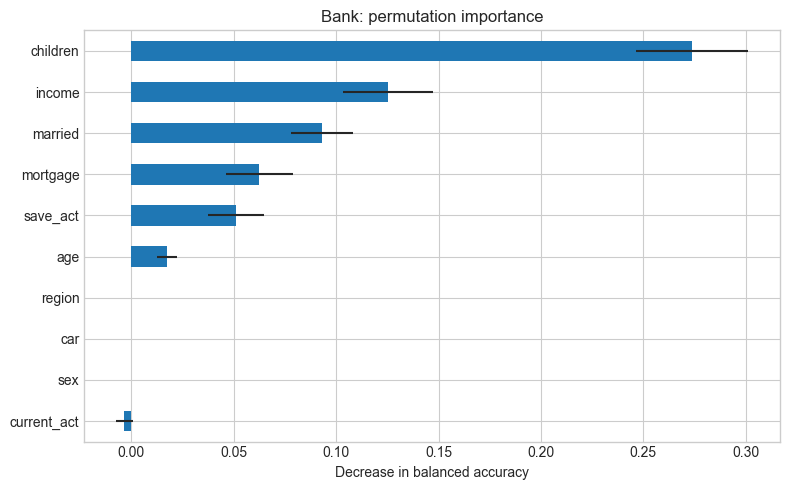

In [23]:
ax = importance_df.sort_values("importance_mean").plot.barh(
    x="feature", y="importance_mean", xerr="importance_sd", legend=False, figsize=(8, 5)
)
ax.set(title="Bank: permutation importance", xlabel="Decrease in balanced accuracy", ylabel="")
plt.tight_layout()


# Fitted tree

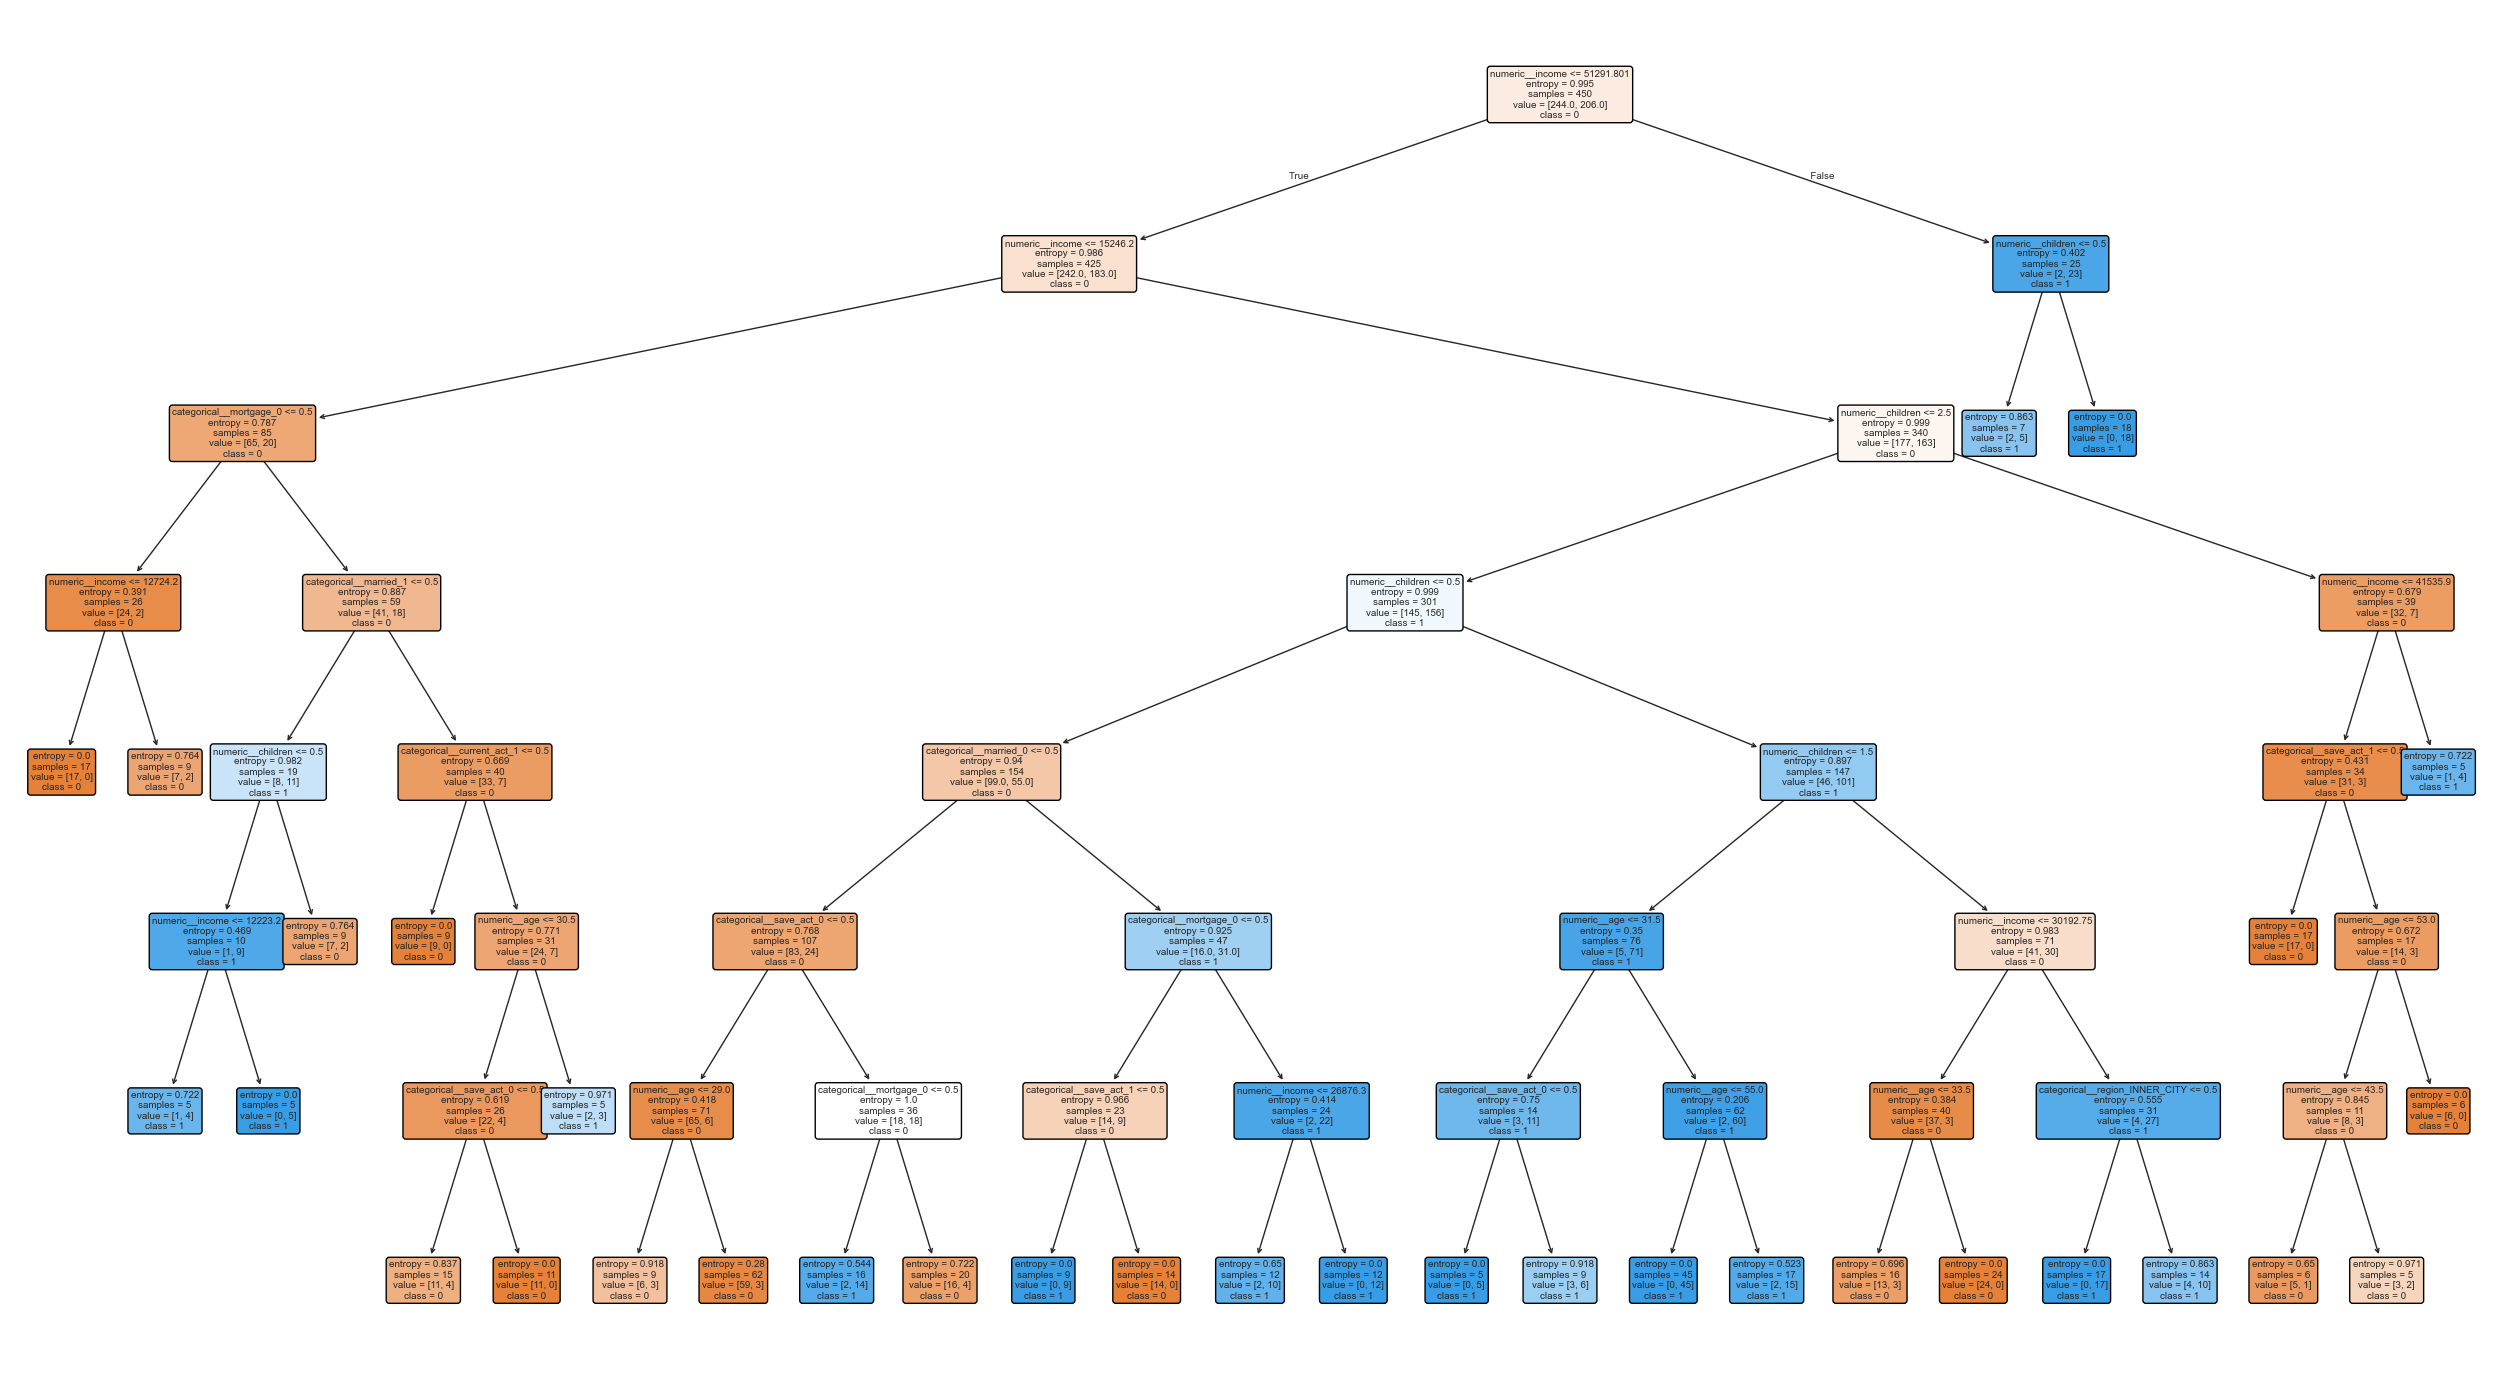

In [24]:
#| echo: false
fitted_tree = best_bank_model.named_steps["model"]
feature_names = best_bank_model.named_steps["preprocess"].get_feature_names_out()

tree_depth = fitted_tree.get_depth()
tree_width = max(18, min(48, 2 ** min(tree_depth, 5)))
plt.figure(figsize=(tree_width, max(10, 2.2 * (tree_depth + 1))))
plot_tree(fitted_tree, feature_names=feature_names, class_names=[str(c) for c in fitted_tree.classes_], filled=True, rounded=True, fontsize=7,)
plt.show()

# Fitted tree (zoom in)

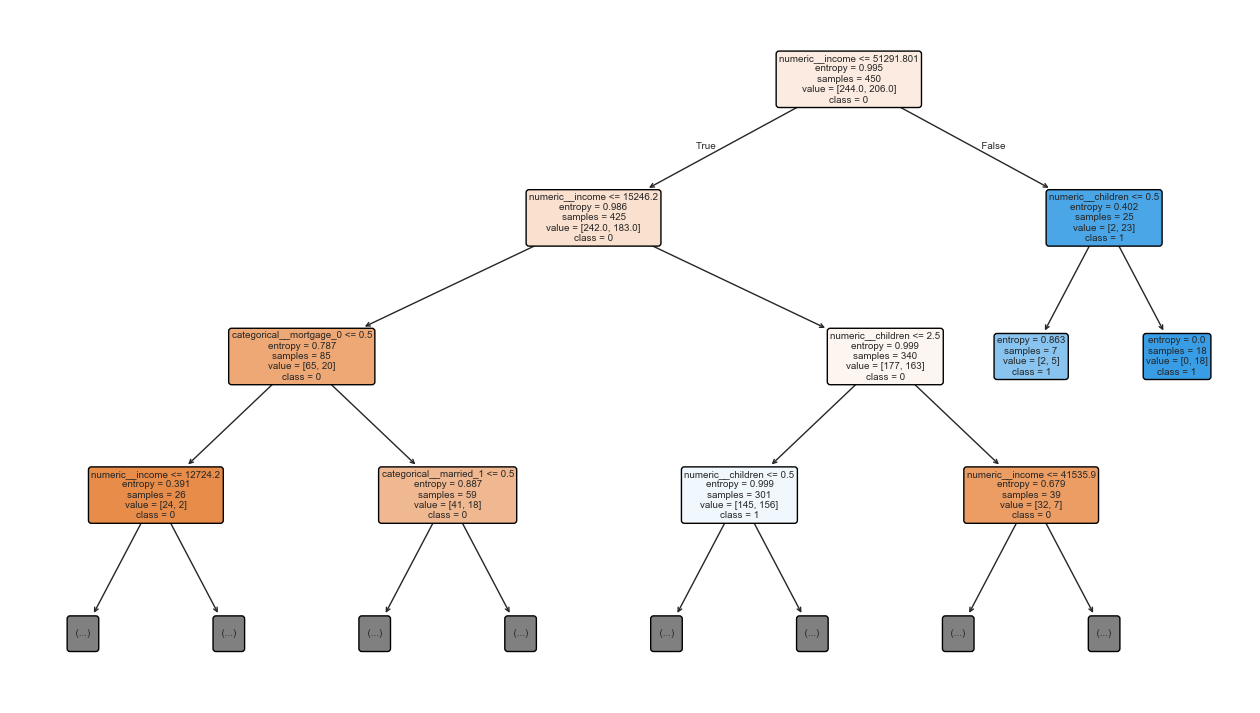

In [25]:
#| echo: false
plt.figure(figsize=(16, 9))
plot_tree(fitted_tree, feature_names=feature_names, class_names=[str(c) for c in fitted_tree.classes_], max_depth=3, filled=True, rounded=True, fontsize=7,)
plt.show()

## Exercise - error analysis

Inspect misclassified rows. Look for patterns, but do not treat a small test sample as proof.

In [26]:
bank_errors = X_test.copy()
bank_errors["actual"] = y_test
bank_errors["predicted"] = bank_pred
bank_errors["p_yes"] = bank_score
bank_errors = bank_errors[bank_errors["actual"] != bank_errors["predicted"]]
print(f"Misclassified rows: {len(bank_errors)} / {len(X_test)}")
bank_errors.sort_values("p_yes").head(8)


Misclassified rows: 19 / 150


,age,sex,region,income,married,children,car,save_act,current_act,mortgage,actual,predicted,p_yes
275,18,MALE,RURAL,9362.58,1,0,1,0,1,1,1,0,0.000000
539,19,MALE,INNER_CITY,10191.80,1,0,0,1,1,1,1,0,0.000000
524,44,MALE,SUBURBAN,18707.30,1,0,1,1,1,1,1,0,0.048387
492,61,FEMALE,TOWN,27756.30,1,0,1,1,0,1,1,0,0.048387
18,62,FEMALE,INNER_CITY,26909.20,1,0,0,1,0,0,1,0,0.048387
597,31,FEMALE,TOWN,15976.30,1,0,1,1,0,0,1,0,0.048387
418,28,FEMALE,TOWN,25699.40,1,2,1,1,0,0,1,0,0.187500
213,28,MALE,TOWN,13175.50,0,1,0,0,1,0,1,0,0.222222


# Census dataset

# Census data: supplied test data and imbalance

The Census task predicts whether annual income is `>50K`.

- Unlike Bank, this dataset supplies separate training and test ARFF files.
- We use training-only cross-validation for decisions and the supplied test set for final evaluation.

In [27]:
census_train.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40,Cuba,<=50K


## Checkpoint - distribution shift

A supplied test set can be harder or easier than the training sample.

1. Are the schemas identical?
2. Are missing values distributed identically?
3. Are target proportions identical?
4. If train and test distributions differ, what does that mean for interpretation?

## Audit train/test compatibility

Check that schemas match, inspect missingness, and compare class prevalence. `fnlwgt` is a survey weight rather than a personal characteristic; we exclude it here. `education` and `education-num` encode closely related information, so we remove the numeric duplicate for a clearer teaching model.

In [28]:
#| echo: false

TARGET = "class"
drop_columns = ["fnlwgt", "education-num"]
census_summary = pd.DataFrame({ "train_missing": census_train.isna().sum(), "test_missing": census_test.isna().sum(), "train_unique": census_train.nunique(dropna=True), "test_unique": census_test.nunique(dropna=True), })
census_summary


,train_missing,test_missing,train_unique,test_unique
age,0,0,66,73
workclass,62,1774,6,8
fnlwgt,0,0,987,21176
education,0,0,16,16
education-num,0,0,16,16
marital-status,0,0,7,7
occupation,62,1781,14,14
relationship,0,0,6,6
race,0,0,5,5
sex,0,0,2,2


## Census target prevalence


In [29]:
prevalence = pd.concat(
    [
        census_train[TARGET].value_counts(normalize=True).rename("train"),
        census_test[TARGET].value_counts(normalize=True).rename("test"),
    ],
    axis=1,
)
prevalence


,train,test
class,,
<=50K,0.768,0.758911
>50K,0.232,0.241089


In [30]:
X_census_train = census_train.drop(columns=[TARGET] + drop_columns)
y_census_train = census_train[TARGET]
X_census_test = census_test.drop(columns=[TARGET] + drop_columns)
y_census_test = census_test[TARGET]

print("Training:", X_census_train.shape, "Test:", X_census_test.shape)

Training: (1000, 12) Test: (31561, 12)


## Select a Census model by cross-validation

The positive class is the less frequent `>50K` group.

- We compare a class-weighted logistic regression, a constrained decision tree, and a random forest.
- Class weighting asks the learner to penalize mistakes on the minority class more strongly; it does not change the evaluation data.

In [31]:
#| echo: false

census_models = {
    "Baseline": classifier_pipeline(
        X_census_train, DummyClassifier(strategy="most_frequent"), scale_numeric=False, impute_missing=True
    ),
    "Weighted logistic regression": classifier_pipeline(
        X_census_train,
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
        impute_missing=True,
    ),
    "Weighted decision tree": classifier_pipeline(
        X_census_train,
        DecisionTreeClassifier(
            max_depth=6, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE
        ),
        scale_numeric=False,
        impute_missing=True,
    ),
    "Weighted random forest": classifier_pipeline(
        X_census_train,
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        scale_numeric=False,
        impute_missing=True,
    ),
}

census_cv_rows = []
for name, workflow in census_models.items():
    scores = cross_validate(workflow, X_census_train, y_census_train, cv=cv, scoring=scoring)
    census_cv_rows.append({
        "model": name,
        **{f"{metric}_mean": scores[f"test_{metric}"].mean() for metric in scoring},
        **{f"{metric}_sd": scores[f"test_{metric}"].std() for metric in scoring},
    })

census_cv_results = pd.DataFrame(census_cv_rows).set_index("model").sort_values(
    "balanced_accuracy_mean", ascending=False
)
census_cv_results.round(3)

,accuracy_mean,balanced_accuracy_mean,f1_mean,accuracy_sd,balanced_accuracy_sd,f1_sd
model,,,,,,
Weighted random forest,0.783,0.796,0.741,0.022,0.022,0.021
Weighted logistic regression,0.791,0.792,0.745,0.012,0.029,0.015
Weighted decision tree,0.748,0.785,0.712,0.025,0.032,0.025
Baseline,0.768,0.500,0.434,0.002,0.000,0.001


## Evaluate the selected Census model once

Choose the highest cross-validated balanced accuracy programmatically, refit it on all training rows, and evaluate it on the supplied test set.

In [32]:
#| echo: false

selected_name = census_cv_results["balanced_accuracy_mean"].idxmax()
selected_census_model = clone(census_models[selected_name]).fit(X_census_train, y_census_train)
census_pred = selected_census_model.predict(X_census_test)
census_test_metrics = pd.Series({
    "accuracy": accuracy_score(y_census_test, census_pred),
    "balanced_accuracy": balanced_accuracy_score(y_census_test, census_pred),
    "macro_f1": f1_score(y_census_test, census_pred, average="macro"),
}, name="supplied_test_score")

print("Selected by CV:", selected_name)
census_test_metrics.to_frame().round(3)

Selected by CV: Weighted random forest


,supplied_test_score
accuracy,0.779
balanced_accuracy,0.796
macro_f1,0.742


## Census supplied test report and confusion matrix


              precision    recall  f1-score   support

       <=50K      0.934     0.762     0.839     23952
        >50K      0.526     0.830     0.644      7609

    accuracy                          0.779     31561
   macro avg      0.730     0.796     0.742     31561
weighted avg      0.835     0.779     0.792     31561



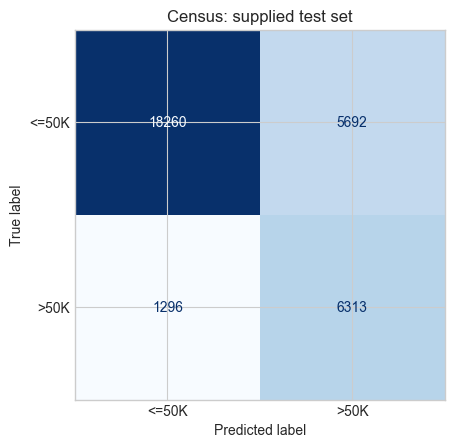

In [33]:
print(classification_report(y_census_test, census_pred, digits=3))
ConfusionMatrixDisplay.from_predictions(y_census_test, census_pred, labels=["<=50K", ">50K"], cmap="Blues", colorbar=False,)
plt.title("Census: supplied test set")
plt.show()


## Slice-based error analysis

Aggregate metrics can hide uneven performance. 

- E.g., the next cell reports accuracy and positive-class recall by `sex`.
- This is a descriptive diagnostic, **not** a fairness verdict: subgroup sizes, label quality, history, deployment context, and the costs of errors all matter.

In [34]:
#| echo: false

census_diagnostics = X_census_test[["sex"]].copy()
census_diagnostics["actual"] = y_census_test.to_numpy()
census_diagnostics["predicted"] = census_pred

slice_rows = []
for group, frame in census_diagnostics.groupby("sex"):
    actual_positive = frame["actual"] == ">50K"
    true_positive = actual_positive & (frame["predicted"] == ">50K")
    slice_rows.append({
        "sex": group,
        "n": len(frame),
        "positive_prevalence": actual_positive.mean(),
        "accuracy": (frame["actual"] == frame["predicted"]).mean(),
        "positive_recall": true_positive.sum() / max(actual_positive.sum(), 1),
    })

pd.DataFrame(slice_rows).set_index("sex").round(3)

,n,positive_prevalence,accuracy,positive_recall
sex,,,,
Female,10442,0.109,0.912,0.609
Male,21119,0.306,0.713,0.868


## Exercise - make a recommendation

Write a short model card paragraph that includes:

1. the prediction target and intended evaluation population;
2. how the model was selected;
3. cross-validation and supplied-test performance;
4. the most important limitation you observed;
5. one additional check required before deployment.

Avoid saying the model is "good" based on accuracy alone.

In [35]:
# Your code here

# Nursery dataset

# Nursery: multiclass extension

Nursery contains categorical features and five target classes.

- The same pipeline pattern works, but evaluation must account for multiple classes and strong imbalance.

## Nursery sample


In [36]:
nursery.head()


,parents,has_nurs,form,children,housing,finance,social,health,class
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority


## Nursery class counts


In [37]:
nursery["class"].value_counts().to_frame("count")


,count
class,
priority,3951
not_recom,3333
spec_prior,2386
very_recom,328
recommend,2


In [38]:
X_nursery = nursery.drop(columns="class")
y_nursery = nursery["class"]
X_nursery_train, X_nursery_test, y_nursery_train, y_nursery_test = train_test_split(
    X_nursery,
    y_nursery,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_nursery,
)


## Multiclass challenge

Complete the workflow below.

1. Compare a baseline, decision tree, and logistic regression with five-fold CV.
2. Select using **macro F1**, which gives each class equal weight.
3. Fit the selected workflow and report a confusion matrix.
4. Identify the class with the lowest recall.

Why might accuracy and macro F1 rank models differently?

In [39]:
# TODO: add at least two learned models.
nursery_models = {
    "Baseline": classifier_pipeline(
        X_nursery_train,
        DummyClassifier(strategy="most_frequent"),
        scale_numeric=False,
    ),
    # "Decision tree": classifier_pipeline(...),
    # "Logistic regression": classifier_pipeline(...),
}

# TODO: use cross_validate(..., scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"})
# TODO: select, fit, predict, and show classification_report and a confusion matrix.

## Key takeaways

- Keep preprocessing inside the pipeline so each validation fold learns it independently.
- Keep a final test set out of model and hyperparameter selection.
- Compare against a baseline and report uncertainty across folds.
- Choose metrics from the error costs and class distribution, not convenience.
- Use confusion matrices and slice analysis to find failures hidden by averages.
- Treat feature importance as a diagnostic of predictive reliance, not a causal explanation.
- A supplied external test set measures generalization to that dataset's population, which may differ from training.